# One model, four forcing datasets

The eWaterCycle [first model run](https://www.ewatercycle.org/getting-started/main/content/first_model_run/first_run.html)
notebook runs the [HBV model](https://hess.copernicus.org/articles/26/1371/2022/) on a
single catchment with Caravan forcing. This notebook keeps the model, the catchment, the
time window and the parameters exactly as they are there, and swaps the forcing:

| forcing | what it is | how it is obtained |
|---|---|---|
| **Caravan** | curated per-catchment dataset, derived from ERA5-Land | downloaded from 4TU |
| **ERA5** | global reanalysis, 0.25° | ESMValTool |
| **ERA5-Land** | land-surface reanalysis, 0.1° | ESMValTool |
| **DestinE** | Climate DT simulation, 0.35° | `ewatercycle-destine`, from the Earth Data Hub |

Everything downstream is held constant, so the differences between the four hydrographs
are differences between the forcing datasets — plus one caveat about the parameters, and
one about DestinE, both spelled out below.

> **This notebook ships unexecuted.** It downloads real data from three services and
> runs a containerised model, so no outputs are committed.

## What you need

```
pip install ewatercycle-HBV ewatercycle-destine
```

* **Caravan** downloads itself, no setup.
* **ERA5 and ERA5-Land** go through ESMValTool, which has to be
  [configured](https://docs.esmvaltool.org/projects/ESMValCore/en/latest/quickstart/configure.html)
  and able to reach the OBS6 tier-3 data. On a machine that is already set up for
  eWaterCycle this is done; on a laptop it usually is not, and those two cells are the
  ones that will fail first.
* **DestinE** needs an Earth Data Hub API key in `EDH_API_KEY` or `~/.netrc`; see
  [`destine_forcing.ipynb`](destine_forcing.ipynb) for the details.
* **HBV** runs in a container, so a container engine has to be available to eWaterCycle.

In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from rich import print

import ewatercycle
import ewatercycle.forcing
import ewatercycle.models

## The catchment and the window

Same basin and same dates as the getting-started notebook. The window sits inside the
DestinE `hist` experiment (1990-2014), so all four datasets cover it.

In [3]:
camels_id = "camelsgb_73010"

experiment_start_date = "2000-08-01T00:00:00Z"
experiment_end_date = "2005-08-31T00:00:00Z"

forcing_root = Path.home() / "forcing_destinE_check" / camels_id

directories = {
    name: forcing_root / name
    for name in ("caravan", "era5", "era5_land", "destine")
}
for path in directories.values():
    path.mkdir(parents=True, exist_ok=True)

print(forcing_root)

/home/mmelotto/forcing_destinE_check/camelsgb_73010

## 1. Caravan

Caravan comes first because it brings two things the others need: the catchment
shapefile, and the observed discharge to compare against.

In [4]:
try:
    caravan = ewatercycle.forcing.sources['CaravanForcing'].load(directory=directories["caravan"])
except:
    caravan = ewatercycle.forcing.sources["CaravanForcing"].generate(
        start_time=experiment_start_date,
        end_time=experiment_end_date,
        directory=directories["caravan"],
        basin_id=camels_id,
    )
print(caravan)

CaravanForcing(
    start_time='2000-08-01T00:00:00Z',
    end_time='2005-08-31T00:00:00Z',
    directory=PosixPath('/home/mmelotto/forcing_destinE_check/camelsgb_73010/caravan'),
    shape=PosixPath('/home/mmelotto/forcing_destinE_check/camelsgb_73010/caravan/camelsgb_73010.shp'),
    filenames={
        'evspsblpot': 'camelsgb_73010_2000-08-01_2005-08-31_evspsblpot.nc',
        'pr': 'camelsgb_73010_2000-08-01_2005-08-31_pr.nc',
        'tasmin': 'camelsgb_73010_2000-08-01_2005-08-31_tasmin.nc',
        'tasmax': 'camelsgb_73010_2000-08-01_2005-08-31_tasmax.nc',
        'tas': 'camelsgb_73010_2000-08-01_2005-08-31_tas.nc',
        'Q': 'camelsgb_73010_2000-08-01_2005-08-31_Q.nc'
    }
)

The shapefile Caravan wrote is what the other three will be clipped to, so all four
datasets see the same catchment outline rather than four slightly different ones.

catchment outline: /home/mmelotto/forcing_destinE_check/camelsgb_73010/caravan/camelsgb_73010.shp

area : 248.1

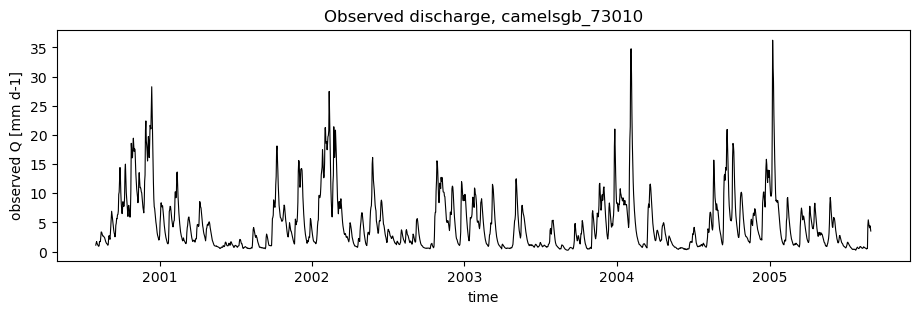

In [5]:
shape = caravan.shape
print("catchment outline:", shape)
print("area [km2]:", round(caravan.get_shape_area() / 1e6, 1))

observed = xr.open_dataset(caravan["Q"])["Q"]
observed.plot(figsize=(11, 3), color="black", linewidth=0.8)
plt.ylabel("observed Q [mm d-1]")
plt.title(f"Observed discharge, {camels_id}")
plt.show()

## 2. ERA5

ERA5 arrives through ESMValTool. `LumpedMakkinkForcing` asks it for `pr`, `tas` and
`rsds` over the catchment, then derives Makkink potential evaporation — the same
`evspsblpot` the DestinE plugin produces, by the same equation.

This cell does the real work of an ESMValTool recipe run, so it is slow the first time.

In [6]:
try:
    load_location = directories["era5"] / "work" / "diagnostic" / "script"  # this is needed because the data is stored in a sub-directory
    era5 = ewatercycle.forcing.sources['LumpedMakkinkForcing'].load(directory=load_location)
except:
    era5 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
        dataset="ERA5",
        start_time=experiment_start_date,
        end_time=experiment_end_date,
        shape=shape,
        directory=directories["era5"],
    )
print(era5)

LumpedMakkinkForcing(
    start_time='2000-08-01T00:00:00Z',
    end_time='2005-08-31T00:00:00Z',
    directory=PosixPath('/home/mmelotto/forcing_destinE_check/camelsgb_73010/era5/work/diagnostic/script'),
    shape=PosixPath('/home/mmelotto/forcing_destinE_check/camelsgb_73010/era5/work/diagnostic/script/camelsgb_73010
.shp'),
    filenames={
        'pr': 'OBS6_ERA5_reanaly_1_day_pr_2000-2005.nc',
        'tas': 'OBS6_ERA5_reanaly_1_day_tas_2000-2005.nc',
        'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_2000-2005.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

## 3. ERA5-Land

The same call with a different dataset name. ERA5-Land is ERA5's land-surface component
rerun at 0.1°, and it is what Caravan itself is built from — so Caravan and ERA5-Land
are close relatives, and it is worth watching whether they behave like it.

In [7]:

try:
    load_location = directories["era5_land"] / "work" / "diagnostic" / "script"  # this is needed because the data is stored in a sub-directory
    era5_land = ewatercycle.forcing.sources['LumpedMakkinkForcing'].load(directory=load_location)
except:
    era5_land = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
        dataset="ERA5-Land",
        start_time=experiment_start_date,
        end_time=experiment_end_date,
        shape=shape,
        directory=directories["era5_land"],
    )
print(era5_land)

LumpedMakkinkForcing(
    start_time='2000-08-01T00:00:00Z',
    end_time='2005-08-31T00:00:00Z',
    directory=PosixPath('/home/mmelotto/forcing_destinE_check/camelsgb_73010/era5_land/work/diagnostic/script'),
    shape=PosixPath('/home/mmelotto/forcing_destinE_check/camelsgb_73010/era5_land/work/diagnostic/script/camelsgb_
73010.shp'),
    filenames={
        'pr': 'OBS6_ERA5-Land_reanaly_1_day_pr_2000-2005.nc',
        'tas': 'OBS6_ERA5-Land_reanaly_1_day_tas_2000-2005.nc',
        'rsds': 'OBS6_ERA5-Land_reanaly_1_day_rsds_2000-2005.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

## 4. DestinE

And the Climate DT, through this plugin. `variant="standard"` is the one that carries
radiation, which Makkink needs.

`DestinELumpedMakkinkForcing` is a `LumpedMakkinkForcing`, so HBV takes it without any
adaptation — the cell below checks exactly that, because it is the property that makes
the plugin usable with a model at all.

In [9]:
try:
    destine = ewatercycle.forcing.sources['LumpedMakkinkForcing'].load(directory=directories["destine"])
except:
    destine = ewatercycle.forcing.sources["DestinELumpedMakkinkForcing"].generate(
        start_time=experiment_start_date,
        end_time=experiment_end_date,
        directory=directories["destine"],
        shape=shape,
        model="IFS-FESOM",
        experiment="hist",
        variant="standard",
    )
print(destine)

ERROR 1: PROJ: internal_proj_create_from_database: /opt/conda/envs/ewatercycle2/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.


DestinELumpedMakkinkForcing(
    start_time='2000-08-01T00:00:00Z',
    end_time='2005-08-31T00:00:00Z',
    directory=PosixPath('/home/mmelotto/forcing_destinE_check/camelsgb_73010/destine'),
    shape=PosixPath('/home/mmelotto/forcing_destinE_check/camelsgb_73010/destine/camelsgb_73010.shp'),
    filenames={
        'pr': 'DestinE_IFS-FESOM_hist_standard_day_pr_2000-08-01_2005-08-31.nc',
        'tas': 'DestinE_IFS-FESOM_hist_standard_day_tas_2000-08-01_2005-08-31.nc',
        'rsds': 'DestinE_IFS-FESOM_hist_standard_day_rsds_2000-08-01_2005-08-31.nc',
        'evspsblpot': 'DestinE_IFS-FESOM_hist_standard_day_evspsblpot_2000-08-01_2005-08-31.nc'
    }
)

### One thing DestinE is not

ERA5, ERA5-Land and Caravan are **reanalyses**: they assimilate observations, so their
rainfall on 12 March 2003 is, to the best of our knowledge, the rainfall that actually
fell on 12 March 2003.

The DestinE Climate DT `hist` experiment is a **free-running climate simulation**. It is
forced with historical greenhouse gases and reproduces the climate of the period — the
seasonal cycle, the distribution of wet and dry days, the statistics — but it is not
synchronised with observed weather. Its 12 March 2003 is a plausible March day, not
*the* March day.

So the DestinE hydrograph below is not supposed to line up with the observations, and no
timing-based score (NSE, KGE) means anything for it. What can fairly be compared is the
regime: the seasonal cycle and the flow duration curve. Both are plotted further down.

## Comparing the forcings before running anything

Four datasets, one catchment. Before touching the model, look at what actually differs
in the inputs.

In [10]:
forcings = {
    "Caravan": caravan,
    "ERA5": era5,
    "ERA5-Land": era5_land,
    "DestinE": destine,
}


def variable(forcing, name):
    """One variable of a forcing object, straight from its own file."""
    return xr.open_dataset(forcing[name])[name].squeeze(drop=True)


summary = pd.DataFrame(
    {
        name: {
            "pr [mm yr-1]": float(variable(forcing, "pr").mean()) * 86400 * 365.25,
            "evspsblpot [mm yr-1]": float(variable(forcing, "evspsblpot").mean())
            * 86400
            * 365.25,
            "tas [degC]": float(variable(forcing, "tas").mean()) - 273.15,
        }
        for name, forcing in forcings.items()
    }
).T
summary.round(1)

,pr [mm yr-1],evspsblpot [mm yr-1],tas [degC]
Caravan,1482.3,836.0,8.1
ERA5,1605.2,541.2,9.5
ERA5-Land,1499.7,514.0,8.1
DestinE,1363.3,537.6,7.3


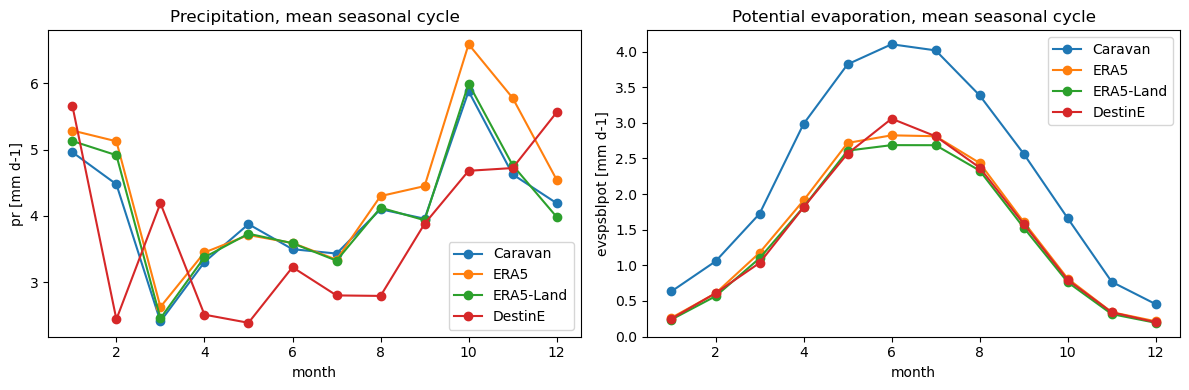

In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))

for name, forcing in forcings.items():
    precipitation = variable(forcing, "pr").groupby("time.month").mean()
    evaporation = variable(forcing, "evspsblpot").groupby("time.month").mean()
    (precipitation * 86400).plot(ax=left, marker="o", label=name)
    (evaporation * 86400).plot(ax=right, marker="o", label=name)

left.set_ylabel("pr [mm d-1]")
left.set_title("Precipitation, mean seasonal cycle")
left.legend()

right.set_ylabel("evspsblpot [mm d-1]")
right.set_title("Potential evaporation, mean seasonal cycle")
right.legend()

fig.tight_layout()
plt.show()

## Setting up HBV

Parameters and initial storages are lifted unchanged from the getting-started notebook.

**They were calibrated for this catchment against Caravan forcing.** That gives Caravan a
head start the other three do not have: some of the spread below is the forcing, and
some is a parameter set that was never tuned for it. Calibrating each forcing separately
is the honest comparison, and is a notebook of its own — see the
[calibration section](https://www.ewatercycle.org/getting-started/main/some_content/workflows/calibrating_models.html)
of the eWaterCycle docs.

In [12]:
parameter_set = [
    7.085,  # Imax
    0.837,  # Ce
    76.373,  # Sumax
    1.112,  # Beta
    0.245,  # Pmax
    7.801,  # Tlag
    0.096,  # Kf
    0.003,  # Ks
    0.226,  # FM
]

initial_conditions = np.array(
    [
        0,  # Si
        100,  # Su
        0,  # Sf
        5,  # Ss
        0,  # Sp
    ]
)

The run itself is the loop from the getting-started notebook, wrapped in a function so
it can be applied to each forcing in turn. `finalize()` sits in a `finally` block: it
shuts down the container, and skipping it after an exception leaves the container
running and eating memory.

In [19]:
def run_hbv(forcing, parameters, initial_storage):
    """Run HBV on one forcing object and return its discharge as a Series."""
    model = ewatercycle.models.HBVLocal(forcing=forcing)
    config_file, _ = model.setup(
        parameters=parameters, initial_storage=initial_storage
    )
    model.initialize(config_file)

    discharge, timestamps = [], []
    try:
        while model.time < model.end_time:
            model.update()
            discharge.append(model.get_value("Q")[0])
            timestamps.append(pd.Timestamp(model.time_as_datetime))
    finally:
        model.finalize()

    return pd.Series(data=discharge, index=timestamps, name="modelled discharge")

In [20]:
runs = {}
for name, forcing in forcings.items():
    print(f"running HBV on {name} forcing...")
    runs[name] = run_hbv(forcing, parameter_set, initial_conditions)

modelled = pd.DataFrame(runs)
modelled.index.name = "time"
modelled.describe().round(2)

running HBV on Caravan forcing...

running HBV on ERA5 forcing...

running HBV on ERA5-Land forcing...

running HBV on DestinE forcing...

,Caravan,ERA5,ERA5-Land,DestinE
count,1856.00,2191.00,2191.00,1856.00
mean,2.56,3.27,3.07,2.76
std,1.98,2.36,2.16,1.71
min,0.00,0.00,0.00,0.00
25%,1.10,1.52,1.49,1.54
50%,1.94,2.54,2.37,2.43
75%,3.54,4.45,4.12,3.64
max,10.67,11.76,12.02,9.70


## The hydrographs

Observed discharge in black, the four model runs on top. Remember that the DestinE line
is a plausible weather sequence rather than the observed one, so read it for its level
and its seasonality, not for whether its peaks land on the right days.

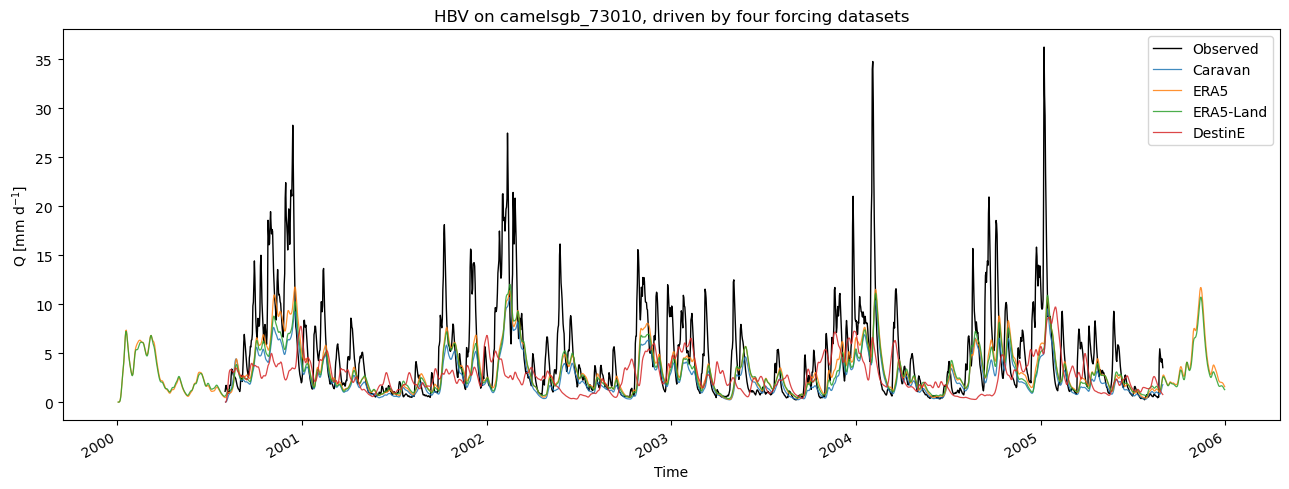

In [25]:
fig, ax = plt.subplots(figsize=(13, 5))

observed.plot(ax=ax, color="black", linewidth=1.0, label="Observed")

for name, series in runs.items():
    ax.plot(
        series.index,
        series.values,
        linewidth=0.9,
        alpha=0.85,
        label=name,
    )

ax.set_ylabel("Q [mm d$^{-1}$]")
ax.set_xlabel("Time")
ax.set_title(f"HBV on {camels_id}, driven by four forcing datasets")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Zooming in on a single winter makes the difference between the reanalysis-driven runs
and the climate-simulation-driven one obvious: the first three rise and fall together
because they saw the same storms, and DestinE does not, because it did not.

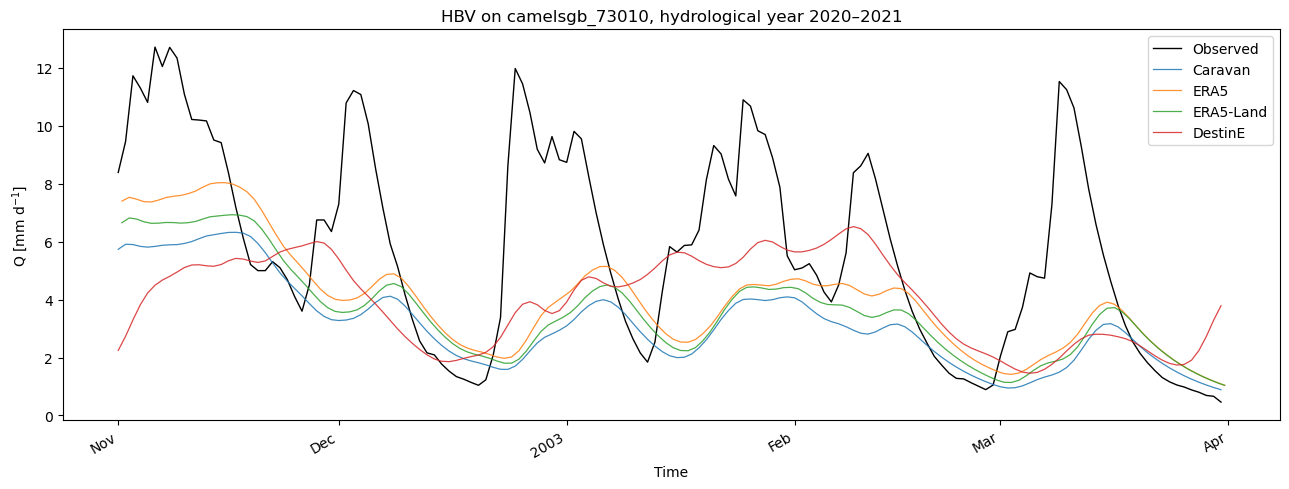

In [28]:
winter_start = "2002-11-01"
winter_end = "2003-03-31"

fig, ax = plt.subplots(figsize=(13, 5))

# Observed
observed_hy = observed.loc[winter_start:winter_end]
observed_hy.plot(
    ax=ax,
    color="black",
    linewidth=1.0,
    label="Observed",
)

# Modelled
for name, series in runs.items():
    series_hy = series.loc[winter_start:winter_end]

    ax.plot(
        series_hy.index,
        series_hy.values,
        linewidth=0.9,
        alpha=0.85,
        label=name,
    )

ax.set_ylabel("Q [mm d$^{-1}$]")
ax.set_xlabel("Time")
ax.set_title(
    f"HBV on {camels_id}, hydrological year 2020–2021"
)
ax.legend()

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Comparing regimes instead of timing

The flow duration curve asks how often a discharge of a given size is exceeded, which
throws away timing entirely. That makes it the fair comparison across all four,
including DestinE.

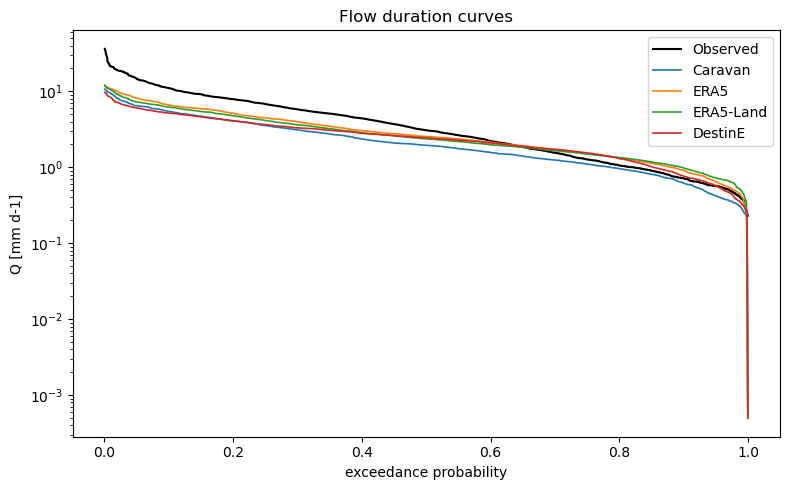

In [29]:
def flow_duration(series):
    """Exceedance probability against discharge, highest flow first."""
    values = np.sort(series.dropna().to_numpy())[::-1]
    exceedance = np.arange(1, values.size + 1) / (values.size + 1)
    return exceedance, values


fig, ax = plt.subplots(figsize=(8, 5))

exceedance, values = flow_duration(observed.to_series())
ax.plot(exceedance, values, color="black", linewidth=1.5, label="Observed")
for name in forcings:
    exceedance, values = flow_duration(modelled[name])
    ax.plot(exceedance, values, linewidth=1.2, label=name)

ax.set_yscale("log")
ax.set_xlabel("exceedance probability")
ax.set_ylabel("Q [mm d-1]")
ax.set_title("Flow duration curves")
ax.legend()
fig.tight_layout()
plt.show()

## Scores, where they mean something

Nash-Sutcliffe efficiency compares day against day, so it is reported only for the three
reanalysis-driven runs. For DestinE it is left out on purpose: a low NSE there would say
nothing about the dataset, only that a climate simulation is not a reanalysis.

In [30]:
def nash_sutcliffe(simulated, observed_series):
    """NSE of two series, over the dates they have in common."""
    joined = pd.concat(
        [simulated.rename("sim"), observed_series.rename("obs")], axis=1
    ).dropna()
    residual = ((joined["sim"] - joined["obs"]) ** 2).sum()
    variance = ((joined["obs"] - joined["obs"].mean()) ** 2).sum()
    return 1 - residual / variance


observed_series = observed.to_series()

scores = pd.DataFrame(
    {
        name: {
            "NSE": (
                "n/a (not time-synchronised)"
                if name == "DestinE"
                else round(nash_sutcliffe(modelled[name], observed_series), 3)
            ),
            "mean Q [mm d-1]": round(float(modelled[name].mean()), 3),
        }
        for name in forcings
    }
).T
scores["observed mean Q [mm d-1]"] = round(float(observed_series.mean()), 3)
scores

/tmp/ipykernel_33508/1826111170.py:8: RuntimeWarning: invalid value encountered in scalar divide


,NSE,mean Q [mm d-1],observed mean Q [mm d-1]
Caravan,0.164,2.561,4.795
ERA5,NaN,3.265,4.795
ERA5-Land,NaN,3.065,4.795
DestinE,n/a (not time-synchronised),2.759,4.795


## Saving the runs

One NetCDF with all four discharge series, so the comparison can be picked up elsewhere.

In [ ]:
output = modelled.to_xarray()
output.attrs["units"] = "mm d-1"
output.attrs["catchment"] = camels_id
output.attrs["model"] = "HBV"
output.attrs["note"] = (
    "DestinE is a free-running climate simulation and is not time-synchronised "
    "with the observations or with the reanalysis-driven runs."
)

out_path = forcing_root / "results" / "hbv_four_forcings.nc"
out_path.parent.mkdir(parents=True, exist_ok=True)
output.to_netcdf(out_path)
print("written to", out_path)

## What to take from this

* Swapping forcing is a one-line change: every one of these objects is a
  `LumpedMakkinkForcing` or a `CaravanForcing`, which is exactly what HBV asks for.
* The reanalysis-driven runs differ from each other mostly in rainfall volume and its
  distribution over the year; the seasonal-cycle plot near the top is where that shows
  up most clearly.
* The DestinE run is a different kind of object: a plausible realisation of the same
  climate rather than a replay of the observed one. Its value is that the same catchment
  can be run forward under `SSP3-7.0` to 2049 with nothing else changed — which is what
  [`destine_forcing.ipynb`](destine_forcing.ipynb) shows.
* One parameter set for four datasets flatters Caravan. Recalibrating per forcing is the
  next step if this is going anywhere near a real answer.